clean Python implementation of SVM on your dataset with:

Data preprocessing

Removing ID column

Removing Unnamed: 32

Encoding labels

Feature scaling

Linear SVM vs RBF SVM comparison

Model evaluation

Visualization (confusion matrix + prediction comparison)





# 1 Import Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 2 Load Dataset

In [5]:
df = pd.read_csv("data.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# 3 Data Preprocessing
Remove unnecessary columns

In [6]:
df = df.drop(columns=['id', 'Unnamed: 32'])

# Encode Diagnosis

M = Malignant = 1
B = Benign = 0

In [7]:
df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0})

# Separate Features and Target

In [8]:
X = df.drop('diagnosis', axis=1)
y = df['diagnosis']

# 4 Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 5 Feature Scaling

SVM depends on distance between data points, so scaling is essential.

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6 Train SVM Models
Linear Kernel

In [11]:
svm_linear = SVC(kernel='linear', C=1)

svm_linear.fit(X_train_scaled, y_train)

y_pred_linear = svm_linear.predict(X_test_scaled)

RBF Kernel

In [12]:
svm_rbf = SVC(kernel='rbf', C=1, gamma='scale')

svm_rbf.fit(X_train_scaled, y_train)

y_pred_rbf = svm_rbf.predict(X_test_scaled)

# 7 Model Accuracy Comparison

In [13]:
print("Linear SVM Accuracy:",
      accuracy_score(y_test, y_pred_linear))

print("RBF SVM Accuracy:",
      accuracy_score(y_test, y_pred_rbf))

Linear SVM Accuracy: 0.9649122807017544
RBF SVM Accuracy: 0.9736842105263158


# 8 Confusion Matrix Visualization

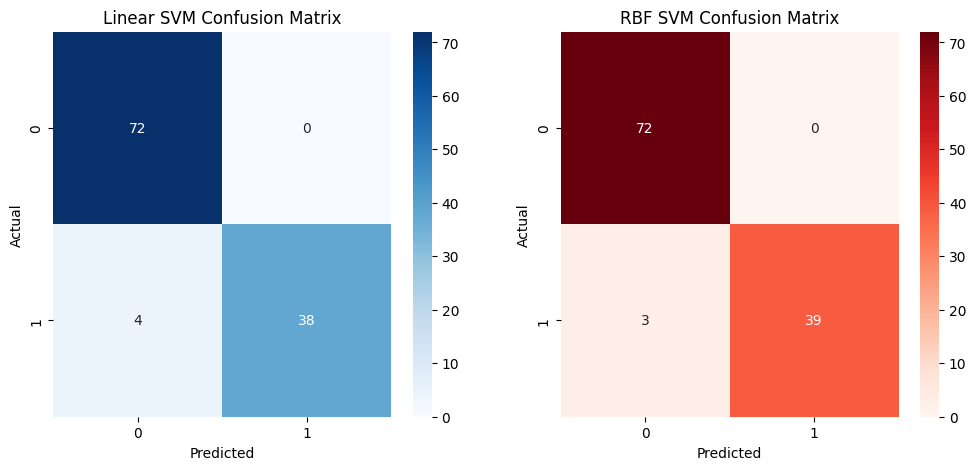

In [14]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.heatmap(confusion_matrix(y_test,y_pred_linear),
            annot=True,
            fmt='d',
            cmap='Blues',
            ax=ax[0])

ax[0].set_title("Linear SVM Confusion Matrix")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test,y_pred_rbf),
            annot=True,
            fmt='d',
            cmap='Reds',
            ax=ax[1])

ax[1].set_title("RBF SVM Confusion Matrix")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("Actual")

plt.show()

# 9 Classification Report

In [15]:
print("Linear SVM Classification Report\n")
print(classification_report(y_test, y_pred_linear))

print("\nRBF SVM Classification Report\n")
print(classification_report(y_test, y_pred_rbf))

Linear SVM Classification Report

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        72
           1       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114


RBF SVM Classification Report

              precision    recall  f1-score   support

           0       0.96      1.00      0.98        72
           1       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



# 10 Model Comparison Visualization

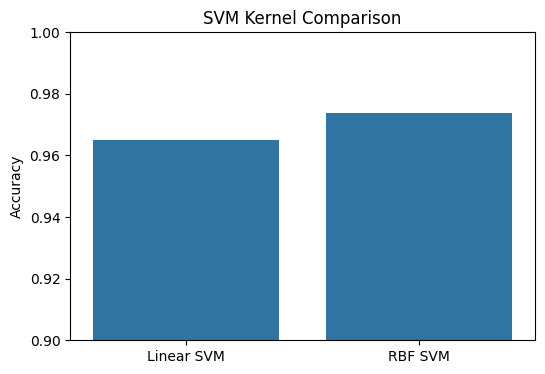

In [16]:
models = ['Linear SVM', 'RBF SVM']
accuracy = [
    accuracy_score(y_test, y_pred_linear),
    accuracy_score(y_test, y_pred_rbf)
]

plt.figure(figsize=(6,4))
sns.barplot(x=models, y=accuracy)
plt.ylabel("Accuracy")
plt.title("SVM Kernel Comparison")
plt.ylim(0.9,1.0)

plt.show()

Raw Data
   ↓
Remove ID & unused column
   ↓
Label Encoding
   ↓
Train-Test Split
   ↓
Feature Scaling
   ↓
Train SVM
   ↓
Linear Kernel vs RBF Kernel
   ↓
Model Evaluation
   ↓
Visualization

# 2 Hyperparameter Tuning with GridSearchCV

Define Parameter Grid

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C':[0.01,0.1,1,10,100],
    'gamma':[1,0.1,0.01,0.001],
    'kernel':['rbf']
}

# Run GridSearchCV

In [18]:
grid = GridSearchCV(
        SVC(),
        param_grid,
        refit=True,
        cv=5,
        verbose=2,
        n_jobs=-1)

grid.fit(X_train_scaled, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'gamma': [1, 0.1, 0.01, 0.001], 'kernel': ['rbf']},
             verbose=2)

In [19]:
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV Score: 0.9758241758241759


In [20]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, y_pred_best))

Test Accuracy: 0.9824561403508771


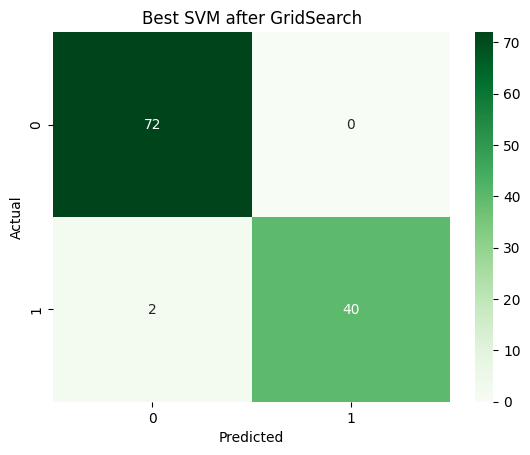

In [21]:
sns.heatmap(confusion_matrix(y_test,y_pred_best),
            annot=True,
            fmt='d',
            cmap='Greens')

plt.title("Best SVM after GridSearch")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Visualizing GridSearch Results

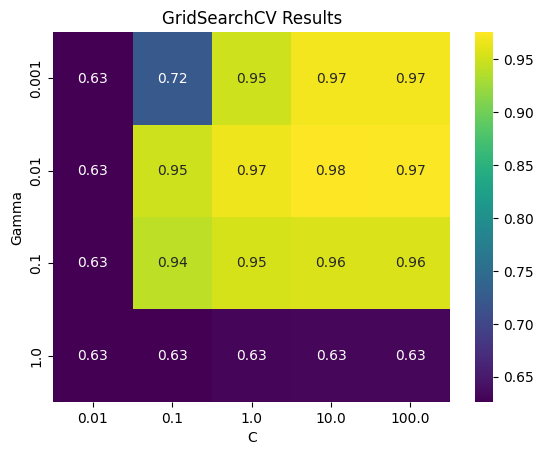

In [22]:
results = pd.DataFrame(grid.cv_results_)

pivot = results.pivot(index='param_gamma',
                      columns='param_C',
                      values='mean_test_score')

sns.heatmap(pivot,
            annot=True,
            cmap='viridis')

plt.title("GridSearchCV Results")
plt.xlabel("C")
plt.ylabel("Gamma")

plt.show()